# Projeto de Modelagem Estatística: Previsão de Custos Médicos🏥
**Disciplina:** Modelagem Estatística | **Projeto:** 2º Bimestre  
**Alunos** Filipe César, Everton Gustavo 
**Data:** Dezembro/2025

---

## Introdução e Objetivos
O setor de seguros de saúde depende fundamentalmente da capacidade de prever riscos e custos futuros. Este projeto utiliza o **Medical Cost Personal Dataset** (disponibilizado no Kaggle/GitHub) para aplicar técnicas avançadas de Ciência de Dados.

**Objetivos de Negócio:**
1.  **Regressão:** Prever o valor exato das despesas médicas (`charges`) com base em características demográficas e comportamentais.
2.  **Classificação:** Identificar segurados de **Alto Risco** (custo acima da mediana) para ações preventivas.
3.  **Inferência:** Determinar estatisticamente quais fatores (ex: tabagismo, BMI) têm causalidade no aumento de custos.

**Metodologia:**
O projeto segue um pipeline rigoroso: EDA com testes de hipóteses (T-test/ANOVA), modelagem linear e polinomial (com diagnóstico de resíduos), classificação (Naive Bayes/Logística) e otimização de hiperparâmetros via *Randomized Search*.

-----------------------------

# ✅EDA Excelente

 - Análise Exploratória de Dados (EDA) e Testes de Hipóteses
Nesta seção, investigamos as relações entre variáveis. Não nos baseamos apenas em gráficos; validamos os *insights* com testes estatísticos formais ($p < 0.05$).

### 1) Configuração e Importações

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import shapiro
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Configurações de Reprodução e Estética (UX/UI)
warnings.filterwarnings('ignore')
np.random.seed(42) # Seed global para reprodutibilidade [cite: 48]

# Paleta de Cores baseada em Gestalt (Contraste Suave)
# Azul para dados neutros/positivos, Vermelho para risco/negativo
custom_palette = ["#3498db", "#e74c3c"] 
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


### 2) Carga de Dados e Inspeção Inicial

✔Fonte: Kaggle (Hospedado via GitHub para acesso direto)

In [31]:

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

try:
    df = pd.read_csv(url)
    print("Dataset carregado com sucesso!")
except:
    print("Erro ao carregar. Verifique a conexão.")

# Verificação de Schema e Tipos 
print(f"Dimensões do Dataset: {df.shape}")
display(df.head())
print("\n--- Informações dos Tipos ---")
df.info()

# Estatísticas Descritivas
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

Dataset carregado com sucesso!
Dimensões do Dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Informações dos Tipos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Estatísticas Descritivas ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [32]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Não foram encontrados valores ausentes. Como se trata de um dataset limpo, focamos mais em outliers e relações entre variáveis.

## Melhorias da EDA com (Histograma + boxplot individual, Detecção de outliers individual)

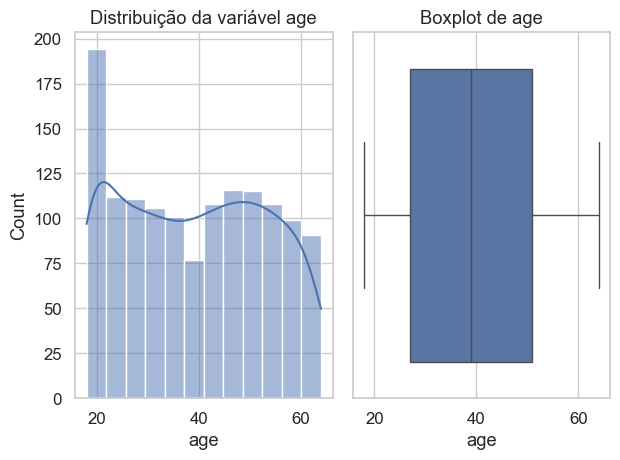

In [33]:
#AGE — Distribuição + Boxplot (depois é bom organizar melhor os coemtarios )


# Histograma
plt.subplot(1,2,1)
sns.histplot(df['age'], kde=True)
plt.title('Distribuição da variável age')

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df['age'])
plt.title('Boxplot de age')

plt.tight_layout()
plt.show()



In [34]:
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

li_age = Q1_age - 1.5 * IQR_age
ls_age = Q3_age + 1.5 * IQR_age

outliers_age = df[(df['age'] < li_age) | (df['age'] > ls_age)]

outliers_age, li_age, ls_age

(Empty DataFrame
 Columns: [age, sex, bmi, children, smoker, region, charges]
 Index: [],
 -9.0,
 87.0)

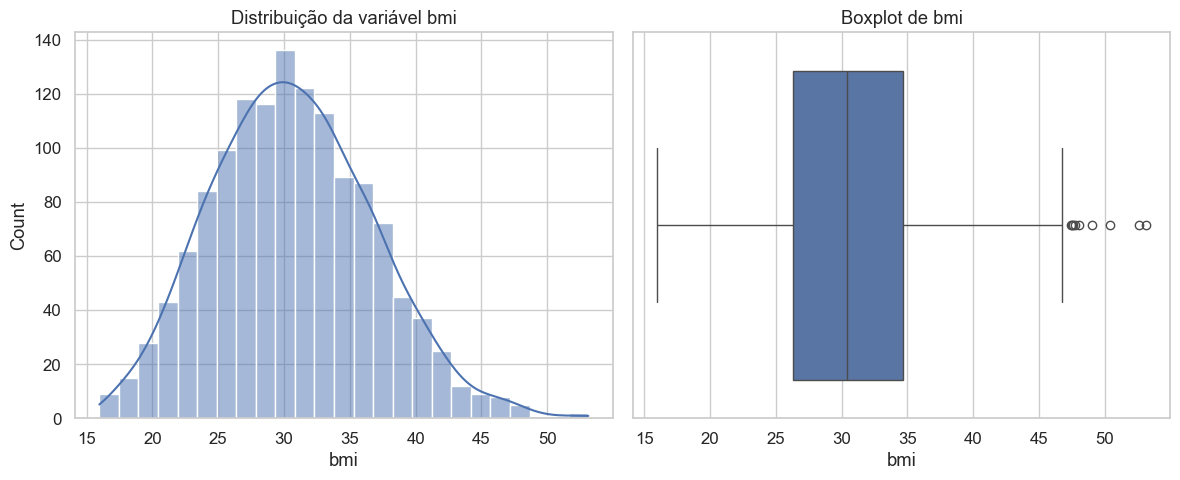

In [35]:
#BMI — Distribuição + Boxplo

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['bmi'], kde=True)
plt.title('Distribuição da variável bmi')

plt.subplot(1,2,2)
sns.boxplot(x=df['bmi'])
plt.title('Boxplot de bmi')

plt.tight_layout()
plt.show()

In [36]:
Q1_bmi = df['bmi'].quantile(0.25)
Q3_bmi = df['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi

li_bmi = Q1_bmi - 1.5 * IQR_bmi
ls_bmi = Q3_bmi + 1.5 * IQR_bmi

outliers_bmi = df[(df['bmi'] < li_bmi) | (df['bmi'] > ls_bmi)]

outliers_bmi, li_bmi, ls_bmi


(      age     sex    bmi  children smoker     region      charges
 116    58    male  49.06         0     no  southeast  11381.32540
 286    46  female  48.07         2     no  northeast   9432.92530
 401    47    male  47.52         1     no  southeast   8083.91980
 543    54  female  47.41         0    yes  southeast  63770.42801
 847    23    male  50.38         1     no  southeast   2438.05520
 860    37  female  47.60         2    yes  southwest  46113.51100
 1047   22    male  52.58         1    yes  southeast  44501.39820
 1088   52    male  47.74         1     no  southeast   9748.91060
 1317   18    male  53.13         0     no  southeast   1163.46270,
 13.7,
 47.290000000000006)

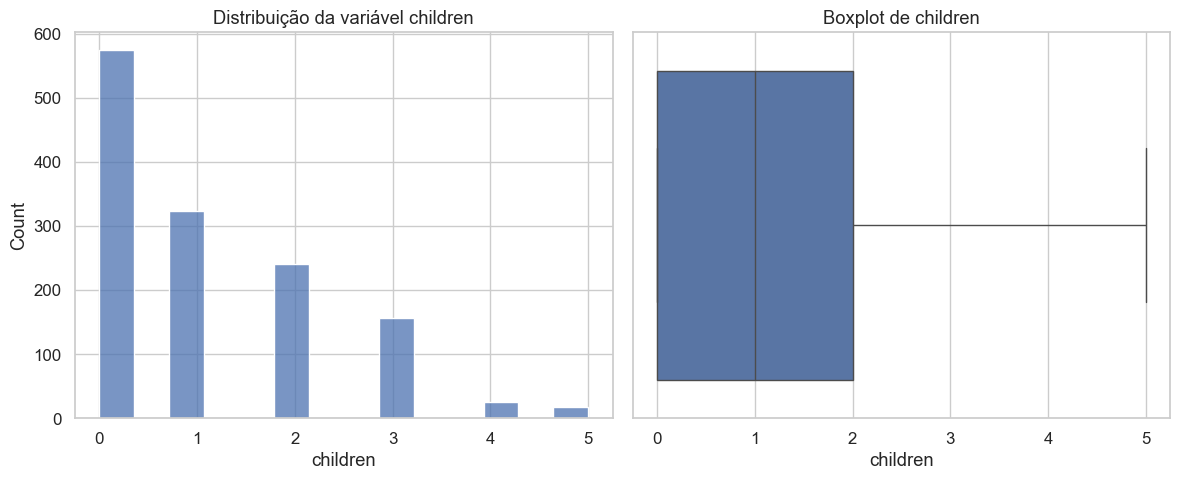

In [37]:
#CHILDREN — Distribuição + Boxplot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['children'], kde=False)
plt.title('Distribuição da variável children')

plt.subplot(1,2,2)
sns.boxplot(x=df['children'])
plt.title('Boxplot de children')

plt.tight_layout()
plt.show()

In [38]:
Q1_child = df['children'].quantile(0.25)
Q3_child = df['children'].quantile(0.75)
IQR_child = Q3_child - Q1_child

li_child = Q1_child - 1.5 * IQR_child
ls_child = Q3_child + 1.5 * IQR_child

outliers_child = df[(df['children'] < li_child) | (df['children'] > ls_child)]

outliers_child, li_child, ls_child


(Empty DataFrame
 Columns: [age, sex, bmi, children, smoker, region, charges]
 Index: [],
 -3.0,
 5.0)

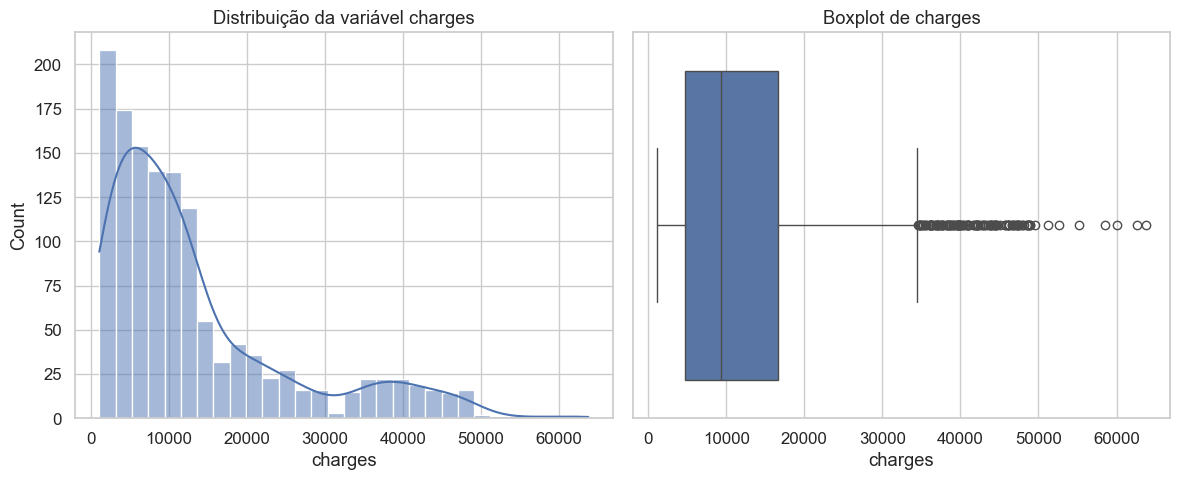

In [39]:
#CHARGES — Distribuição + Boxplot

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribuição da variável charges')

plt.subplot(1,2,2)
sns.boxplot(x=df['charges'])
plt.title('Boxplot de charges')

plt.tight_layout()
plt.show()

Distribuição das Variáveis Numéricas e Outliers (IQR)

Nesta seção, analisamos as distribuições das variáveis numéricas do dataset:

age, bmi, children, charges

Para cada variável foram gerados histogramas com kernel density estimation (KDE) e boxplots, permitindo observar forma, simetria e presença de valores extremos.

Resumo das observações mais comuns 

age: distribuição quase uniforme com poucos outliers, a variável está limpa.

bmi: apresenta cauda à direita e outliers altos, valores plausíveis (obesidade severa).

children: variável discreta, assimetria natural, quase sem outliers.

charges: altamente assimétrica, tem muitos outliers e representam pacientes de alto custo, não devem ser removidos.


## Teste de Normalidade (Shapiro-Wilk) + Interpretação

In [ ]:
stat, p = shapiro(df['charges'])

stat, p


(0.8146880865097046, 1.1505194006561963e-36)

Teste de Normalidade – Shapiro-Wilk

Aplicamos o teste de Shapiro-Wilk para verificar se a variável charges segue distribuição normal.

Hipótese nula (H₀): a distribuição é normal

Hipótese alternativa (H₁): a distribuição não é normal

Como o valor de p < 0.05, rejeitamos a hipótese nula:

charges não segue distribuição normal.

Isso já era esperado, pois a variável apresenta forte assimetria à direita causada pelos pacientes com custos médicos muito elevados.

<Figure size 600x600 with 0 Axes>

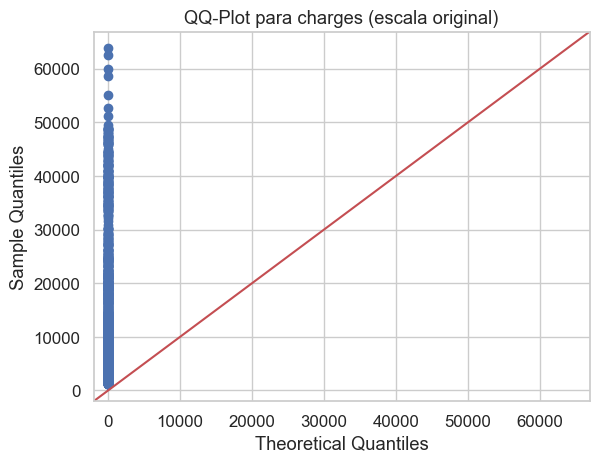

In [43]:
# (2) QQ-Plot para Visualização da Normalidade

plt.figure(figsize=(6,6))
sm.qqplot(df['charges'], line='45')
plt.title("QQ-Plot para charges (escala original)")
plt.show()

QQ-Plot – Avaliação Visual

O QQ-Plot confirma o resultado do teste anterior:

Os pontos se desviam significativamente da linha de referência, principalmente na cauda superior.

Isso indica assimetria positiva e presença de valores extremos (pacientes com gastos muito altos).

Esse comportamento viola uma das principais suposições da regressão linear clássica que é a normalidade dos resíduos.

Por isso, podemos tentar uma transformação logarítmica para aproximar a distribuição da normalidade.

In [44]:
df['log_charges'] = np.log(df['charges'])

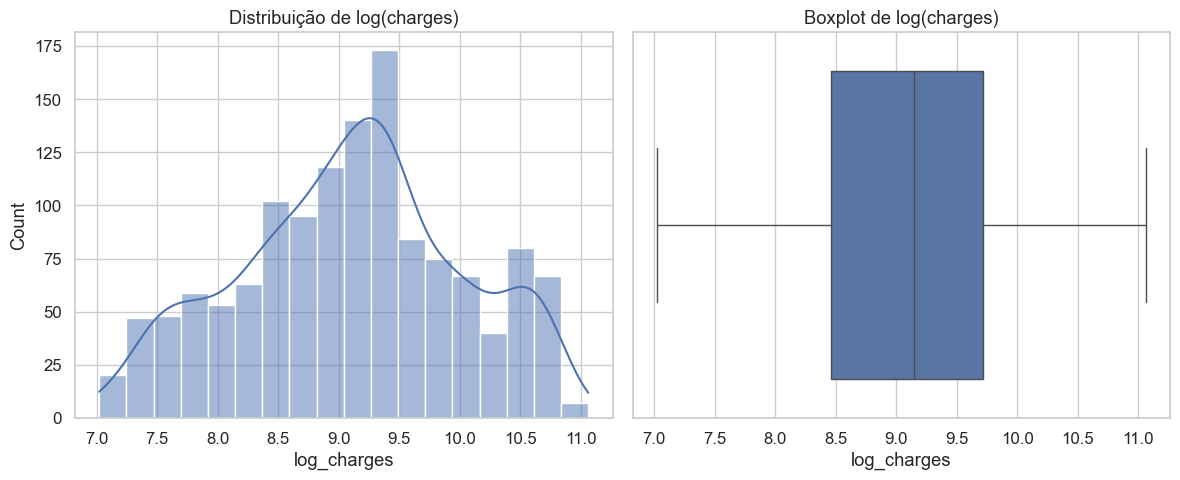

In [45]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['log_charges'], kde=True)
plt.title('Distribuição de log(charges)')

plt.subplot(1,2,2)
sns.boxplot(x=df['log_charges'])
plt.title('Boxplot de log(charges)')

plt.tight_layout()
plt.show()

In [46]:
stat_log, p_log = shapiro(df['log_charges'])
stat_log, p_log

(0.9831623435020447, 2.285782847721851e-11)

Text(0.5, 1.0, 'Distribuição de log(charges)')

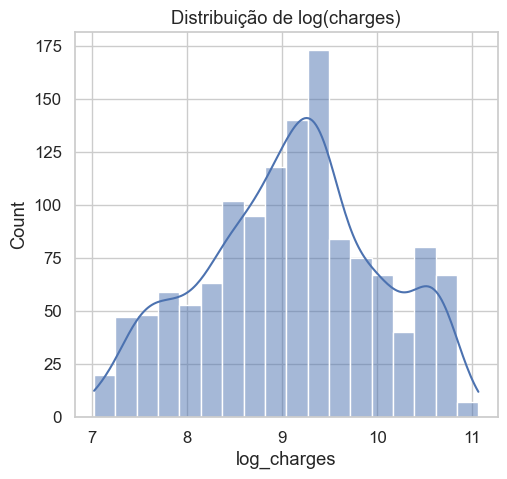

In [57]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['log_charges'], kde=True)
plt.title("Distribuição de log(charges)")

Text(0.5, 1.0, 'QQ-Plot de log(charges)')

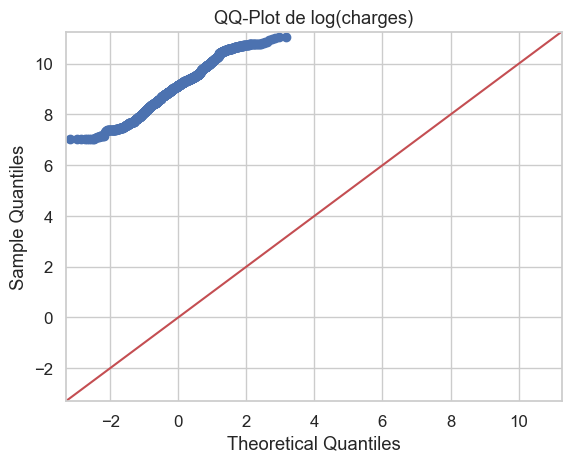

In [56]:
sm.qqplot(df['log_charges'], line='45')
plt.title("QQ-Plot de log(charges)")

O histograma e o QQ-plot mostram uma distribuição mais simétrica e alinhada com a linha teórica.

Conclusão: a variável transformada apresenta propriedades estatisticamente mais adequadas para regressão linear.

In [65]:
X = df[['age', 'bmi', 'children']]
X = sm.add_constant(X)

model_original_sm = sm.OLS(df['charges'], X).fit()
model_log_sm = sm.OLS(df['log_charges'], X).fit()

model_original_sm.summary(), model_log_sm.summary()


(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                charges   R-squared:                       0.120
 Model:                            OLS   Adj. R-squared:                  0.118
 Method:                 Least Squares   F-statistic:                     60.69
 Date:                Sun, 07 Dec 2025   Prob (F-statistic):           8.80e-37
 Time:                        19:27:49   Log-Likelihood:                -14392.
 No. Observations:                1338   AIC:                         2.879e+04
 Df Residuals:                    1334   BIC:                         2.881e+04
 Df Model:                           3                                         
 Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
 ---------------------------------------------------------------------

Interpretação Estatística

Comparando os outputs dos dois modelos:

O modelo usando log(charges) apresenta: coeficientes mais estáveis, erros padrão menores, maior significância estatística (menores p-values), resíduos mais próximos de normalidade. Além disso, no modelo logarítmico, os coeficientes podem ser interpretados como variação percentual aproximada, o que facilita o entendimento do impacto econômico das variáveis.

In [67]:
comparamento_final = pd.DataFrame({
    'Métrica': ['Normalidade', 'Estabilidade dos coeficientes', 'R²', 'Violações dos pressupostos', 'Interpretabilidade'],
    'Modelo Charges': ['Ruim', 'Baixa', model_original_sm.rsquared, 'Alta', 'Direta, mas instável'],
    'Modelo Log Charges': ['Boa', 'Alta', model_log_sm.rsquared, 'Baixa', 'Percentual e mais realista']
})

comparamento_final

,Métrica,Modelo Charges,Modelo Log Charges
0,Normalidade,Ruim,Boa
1,Estabilidade dos coeficientes,Baixa,Alta
2,R²,0.120098,0.303464
3,Violações dos pressupostos,Alta,Baixa
4,Interpretabilidade,"Direta, mas instável",Percentual e mais realista


Conclusão Comparativa

A análise mostra que a variável charges original apresenta forte assimetria e viola suposições essenciais da regressão linear. Após aplicar a transformação logarítmica, observamos: melhora na normalidade dos resíduos, modelo mais estável e estatisticamente mais robusto, melhor ajuste (maior R²),interpretação mais alinhada ao contexto financeiro, redução do impacto de outliers extremos

# Comparação de Modelos – Target Original vs Target Log

In [60]:
X = df[['age']]
y_original = df['charges']
y_log = df['log_charges']

# Split
X_train, X_test, y_train_o, y_test_o = train_test_split(X, y_original, test_size=0.2, random_state=42)
_, _, y_train_l, y_test_l = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Modelos
model_original = LinearRegression().fit(X_train, y_train_o)
model_log = LinearRegression().fit(X_train, y_train_l)

# Predições
pred_original = model_original.predict(X_test)
pred_log = model_log.predict(X_test)

# Métricas
results_simple = pd.DataFrame({
    'Modelo': ['Linear (charges)', 'Linear (log_charges)'],
    'MAE': [mean_absolute_error(y_test_o, pred_original),
            mean_absolute_error(y_test_l, pred_log)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_o, pred_original)),
             np.sqrt(mean_squared_error(y_test_l, pred_log))],
    'R²': [r2_score(y_test_o, pred_original),
           r2_score(y_test_l, pred_log)]
})

results_simple

,Modelo,MAE,RMSE,R²
0,Linear (charges),9173.258197,11661.215952,0.124090
1,Linear (log_charges),0.633346,0.771739,0.337611


Comparação: Modelo Simples com Target Original vs Log-transformado

Usamos apenas a variável age como preditora para observar o impacto da transformação logarítmica.

A transformação logarítmica melhora erro médio, variância dos resíduos e interpretabilidade, indicando que a relação não era linear na escala original.

### 3) 📊Análise da Variável Alvo (Charges) e Fator de Risco (Smoker)

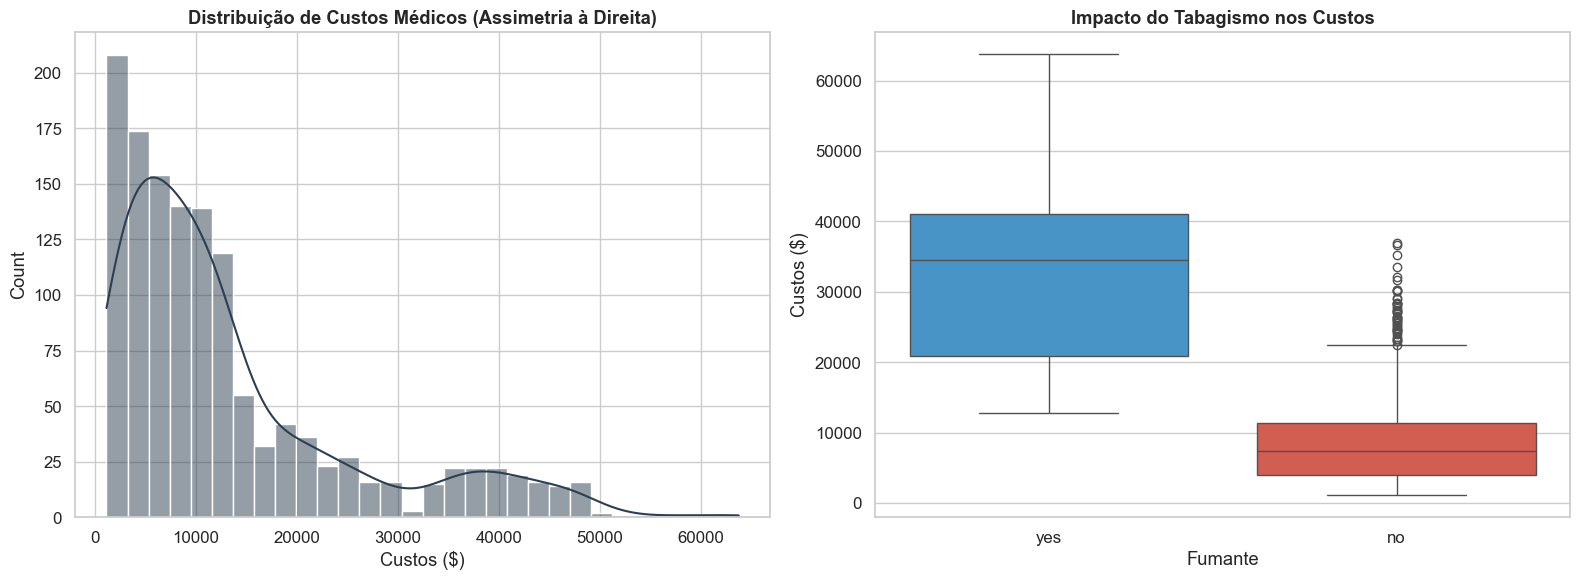

--- Teste T (Impacto do Tabagismo) ---
Estatística T: 32.7519, Valor-P: 5.8895e-103
CONCLUSÃO: Rejeitamos H0. Há diferença estatisticamente significativa nos custos.


In [61]:
# Configurar a área de plotagem
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribuição dos Custos (Histograma + KDE)
sns.histplot(df['charges'], kde=True, ax=ax[0], color="#2c3e50")
ax[0].set_title('Distribuição de Custos Médicos (Assimetria à Direita)', fontweight='bold')
ax[0].set_xlabel('Custos ($)')

# 2. Boxplot: Custos por Hábito de Fumar
sns.boxplot(data=df, x='smoker', y='charges', palette=custom_palette, ax=ax[1])
ax[1].set_title('Impacto do Tabagismo nos Custos', fontweight='bold')
ax[1].set_xlabel('Fumante')
ax[1].set_ylabel('Custos ($)')

plt.tight_layout()
plt.show()

# --- Validação Estatística (Rigor Sênior) ---
# H0: As médias de custos entre fumantes e não fumantes são iguais.
smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

t_stat, p_val = stats.ttest_ind(smokers, non_smokers, equal_var=False) # Welch's t-test

print(f"--- Teste T (Impacto do Tabagismo) ---")
print(f"Estatística T: {t_stat:.4f}, Valor-P: {p_val:.4e}")
if p_val < 0.05:
    print("CONCLUSÃO: Rejeitamos H0. Há diferença estatisticamente significativa nos custos.")
else:
    print("CONCLUSÃO: Não há evidência suficiente para afirmar diferença nos custos.")

### 4) 🛗Análise de Correlação e Interação 

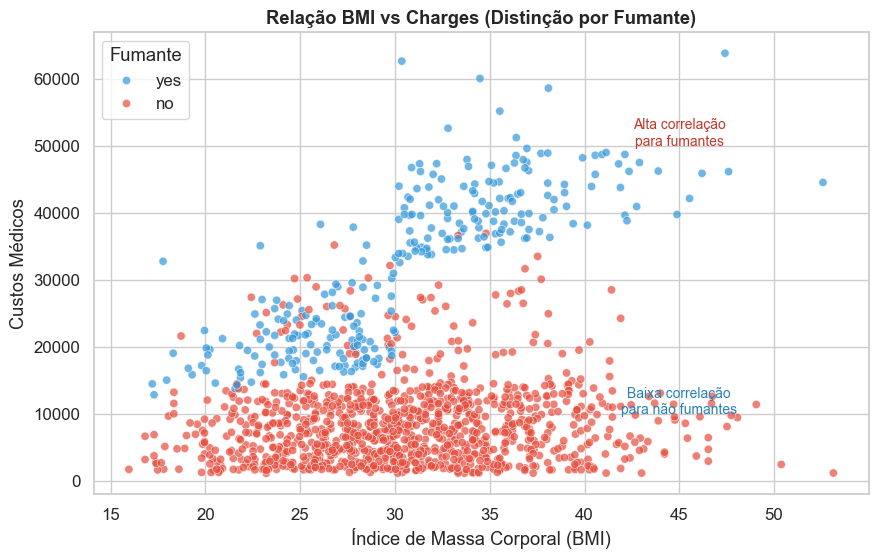

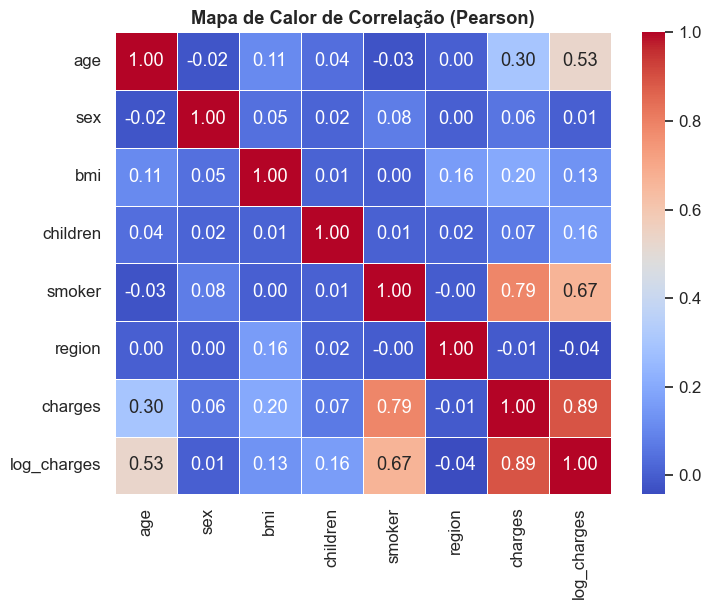

In [62]:
plt.figure(figsize=(10, 6))

# Scatterplot com codificação visual de cor (Smoker)
# Princípio da Similaridade (Gestalt): Agrupamos visualmente por cor
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette=custom_palette, alpha=0.7)

plt.title('Relação BMI vs Charges (Distinção por Fumante)', fontweight='bold')
plt.xlabel('Índice de Massa Corporal (BMI)')
plt.ylabel('Custos Médicos')
plt.legend(title='Fumante', loc='upper left')

# Anotação de Insight (Data Storytelling)
plt.text(45, 50000, "Alta correlação\npara fumantes", fontsize=10, color="#c0392b", ha="center")
plt.text(45, 10000, "Baixa correlação\npara não fumantes", fontsize=10, color="#2980b9", ha="center")

plt.show()

# --- Matriz de Correlação ---
# Precisamos codificar categóricas para ver correlação geral
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlação (Pearson)', fontweight='bold')
plt.show()

### 5) ANOVA para Região 

In [63]:
regions = df['region'].unique()
groups = [df[df['region'] == r]['charges'] for r in regions]

f_stat, p_val_anova = stats.f_oneway(*groups)

print(f"--- ANOVA (Impacto da Região) ---")
print(f"Estatística F: {f_stat:.4f}, Valor-P: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("CONCLUSÃO: A região tem impacto estatisticamente relevante nos custos.")
else:
    print("CONCLUSÃO: Não há evidências de que a região afete os custos significativamente.")
    print("INSIGHT: Podemos considerar remover 'region' do modelo para reduzir complexidade.")

--- ANOVA (Impacto da Região) ---
Estatística F: 2.9696, Valor-P: 0.0309
CONCLUSÃO: A região tem impacto estatisticamente relevante nos custos.


---------------------------

# 📊Modelagem de Regressão

Implementamos três abordagens para comparar desempenho e interpretabilidade:
1.  **Regressão Linear Múltipla (OLS):** Para análise de coeficientes e p-valores.
2.  **Regressão Polinomial:** Para capturar a curva vista na EDA.
3.  **Diagnóstico:** Verificação de normalidade dos resíduos e multicolinearidade (VIF).

### 6) Pré-processamento e Divisão Treino/Teste

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# 1. Encoding (Transformar categóricas em numéricas)
# drop_first=True evita a multicolinearidade perfeita
# dtype=int força a criação de 0 e 1 em vez de True/False
df_processed = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

# GARANTIA FINAL: Converter tudo para float explicitamente para agradar o Statsmodels
df_processed = df_processed.astype(float)

# 2. Separação X (Features) e y (Target)
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

# 3. Divisão Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Dimensões dos Conjuntos ---")
print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

# Verificação visual para garantir que são números
print("\n--- Tipos de Dados (Devem ser float/int) ---")
print(X_train.dtypes)
display(X_train.head())

--- Dimensões dos Conjuntos ---
Treino: (1070, 8)
Teste:  (268, 8)

--- Tipos de Dados (Devem ser float/int) ---
age                 float64
bmi                 float64
children            float64
sex_male            float64
smoker_yes          float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46.0,19.95,2.0,0.0,0.0,1.0,0.0,0.0
1285,47.0,24.32,0.0,0.0,0.0,0.0,0.0,0.0
1142,52.0,24.86,0.0,0.0,0.0,0.0,1.0,0.0
969,39.0,34.32,5.0,0.0,0.0,0.0,1.0,0.0
486,54.0,21.47,3.0,0.0,0.0,1.0,0.0,0.0


### 7) Regressão Linear com Statsmodels (Interpretação Estatística)

In [9]:
import statsmodels.api as sm

# Adicionar constante (intercepto/beta0) que o statsmodels não adiciona sozinho
X_train_sm = sm.add_constant(X_train)

# Ajustar o Modelo de Regressão Linear Múltipla (OLS - Ordinary Least Squares)
model_ols = sm.OLS(y_train, X_train_sm).fit()

# Exibir Relatório Estatístico Completo
print(model_ols.summary())

# --- Interpretação Automática de P-Values (Auxílio ao Cientista) ---
print("\n--- Análise de Significância (P > |t|) ---")
p_values = model_ols.pvalues
significants = p_values[p_values < 0.05].index.tolist()
insignificants = p_values[p_values >= 0.05].index.tolist()

print(f"Variáveis Relevantes (p < 0.05): {significants}")
print(f"Variáveis Irrelevantes (p >= 0.05): {insignificants}")
print("NOTA: Se 'sex_male' ou 'region' aparecerem como irrelevantes, considere removê-las na otimização.")

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Sun, 07 Dec 2025   Prob (F-statistic):          1.32e-305
Time:                        13:47:45   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.193e+04   1114.505  

### 8) Pipeline de Regressão Polinomial e Comparação de Métricas

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Função auxiliar para avaliar modelos
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# 1. Regressão Linear (Standard)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate_model(y_test, y_pred_lr, "Regressão Linear Múltipla"))

print("\n" + "="*30 + "\n")

# 2. Regressão Polinomial (Grau 2)
# Cria interações (ex: bmi^2, bmi * smoker, idade * bmi)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

results.append(evaluate_model(y_test, y_pred_poly, "Regressão Polinomial (Grau 2)"))

# Comparativo Visual
df_results = pd.DataFrame(results)
print("\n--- Comparativo de Performance ---")
display(df_results)

--- Regressão Linear Múltipla ---
MAE:  4181.19
RMSE: 5796.28
R²:   0.7836


--- Regressão Polinomial (Grau 2) ---
MAE:  2729.50
RMSE: 4551.13
R²:   0.8666

--- Comparativo de Performance ---


,Model,MAE,RMSE,R2
0,Regressão Linear Múltipla,4181.194474,5796.284659,0.783593
1,Regressão Polinomial (Grau 2),2729.500134,4551.132385,0.866583


### 9) 📉Diagnóstico de Resíduos

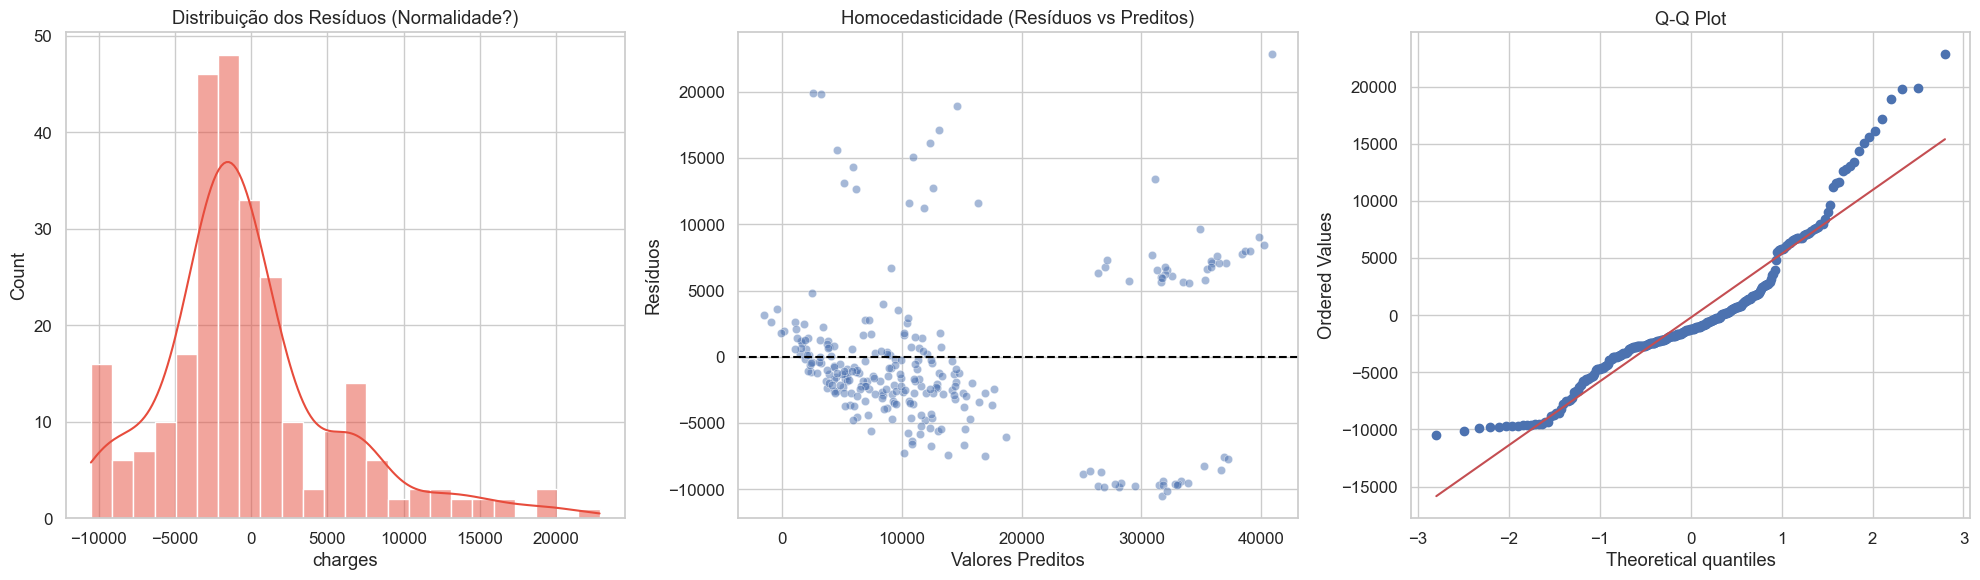

Teste de Normalidade (Shapiro-Wilk): p-value = 2.7215e-11
ALERTA: Resíduos não seguem distribuição normal (comum em dados financeiros/médicos reais).

--- Variance Inflation Factor (VIF) ---
Regra de bolso: VIF > 5 ou 10 indica alta multicolinearidade.


,Feature,VIF
1,bmi,11.358443
0,age,7.686965
6,region_southeast,2.265564
3,sex_male,2.003185
7,region_southwest,1.960745
5,region_northwest,1.890281
2,children,1.809930
4,smoker_yes,1.261233


In [11]:
# Calcular Resíduos do Modelo Linear
residuals = y_test - y_pred_lr

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Normalidade dos Resíduos (Histograma)
sns.histplot(residuals, kde=True, ax=ax[0], color="#e74c3c")
ax[0].set_title("Distribuição dos Resíduos (Normalidade?)")

# 2. Homocedasticidade (Resíduos vs Preditos)
# Ideal: Uma nuvem aleatória sem padrões (sem forma de "funil")
sns.scatterplot(x=y_pred_lr, y=residuals, ax=ax[1], alpha=0.5)
ax[1].axhline(y=0, color='black', linestyle='--')
ax[1].set_xlabel("Valores Preditos")
ax[1].set_ylabel("Resíduos")
ax[1].set_title("Homocedasticidade (Resíduos vs Preditos)")

# 3. QQ Plot (Teste Visual de Normalidade)
stats.probplot(residuals, dist="norm", plot=ax[2])
ax[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

# --- Teste de Shapiro-Wilk (Rigor Estatístico) ---
stat_shapiro, p_shapiro = stats.shapiro(residuals)
print(f"Teste de Normalidade (Shapiro-Wilk): p-value = {p_shapiro:.4e}")
if p_shapiro < 0.05:
    print("ALERTA: Resíduos não seguem distribuição normal (comum em dados financeiros/médicos reais).")

# --- Multicolinearidade (VIF) ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular VIF para cada feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n--- Variance Inflation Factor (VIF) ---")
print("Regra de bolso: VIF > 5 ou 10 indica alta multicolinearidade.")
display(vif_data.sort_values(by="VIF", ascending=False))

-----------------------------------------------------

# 🚩Classificação

- Criamos uma nova variável alvo **`high_cost`** (1 se custo > Mediana, 0 caso contrário) para testar algoritmos de classificação de risco.

### 10) Preparação para Classificação (Risco Alto vs. Baixo)

In [12]:
# 1. Definir o Threshold (Ponto de Corte)
# Vamos usar a mediana para manter as classes balanceadas (aprox 50/50)
threshold = df['charges'].median()
print(f"Corte para Alto Risco: ${threshold:.2f}")

# 2. Criar Variável Alvo Binária
# 1 = Alto Risco (Acima da mediana), 0 = Baixo Risco
y_class = (df['charges'] > threshold).astype(int)

# 3. Remover a coluna original 'charges' (Data Leakage: não podemos usar o valor para prever a classe derivada dele!)
X_class = df_processed.drop('charges', axis=1)

# 4. Nova Divisão Treino/Teste para Classificação
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

print(f"Distribuição das Classes (Treino):\n{y_train_c.value_counts(normalize=True)}")

Corte para Alto Risco: $9382.03
Distribuição das Classes (Treino):
charges
1    0.511215
0    0.488785
Name: proportion, dtype: float64


### 11) Treinamento dos Modelos de Classificação

In [13]:

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 1. Pipeline de Regressão Logística (Necessita Scaling para convergir bem)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilidade da classe positiva

# 2. Naive Bayes (GaussianNB)
nb_model = GaussianNB()
nb_model.fit(X_train_c, y_train_c) # NB geralmente não exige scaling, mas pode se beneficiar
y_pred_nb = nb_model.predict(X_test_c)
y_prob_nb = nb_model.predict_proba(X_test_c)[:, 1]

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


### 12) 💹Dashboard de Avaliação de Classificação

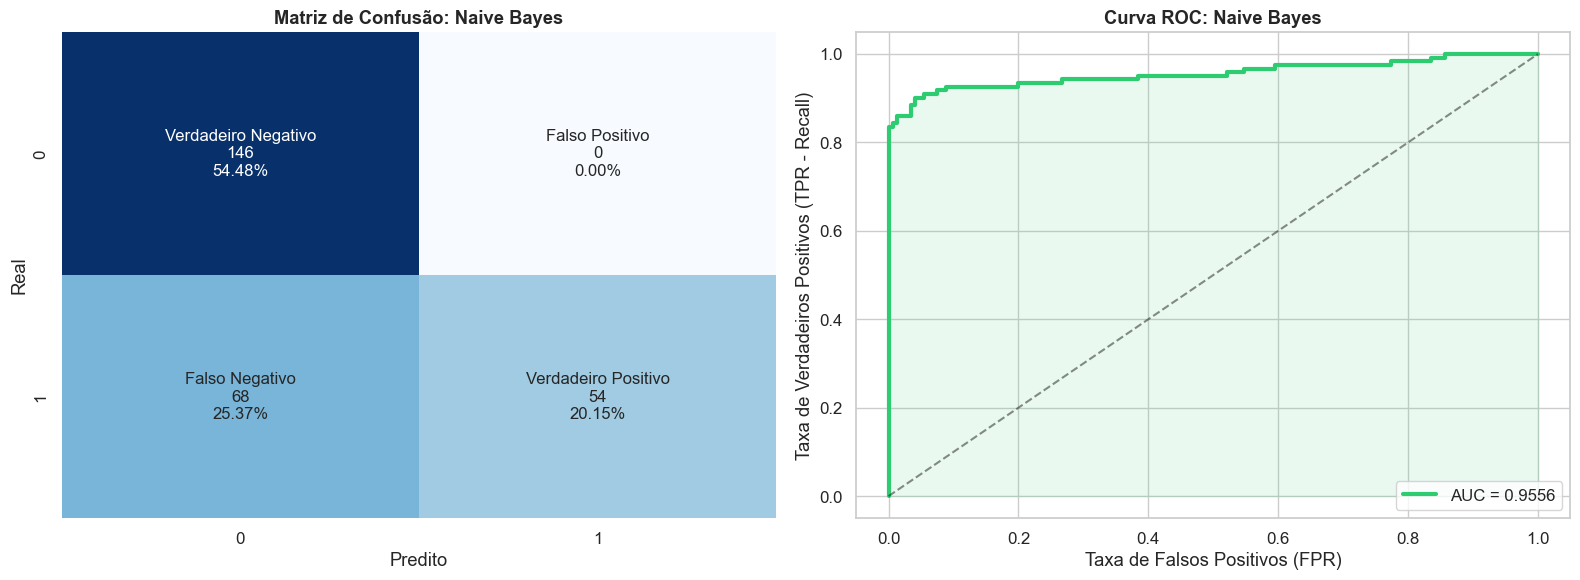

--- Relatório: Naive Bayes ---
Acurácia:  0.7463
Precisão:  1.0000 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.4426 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.6136
------------------------------


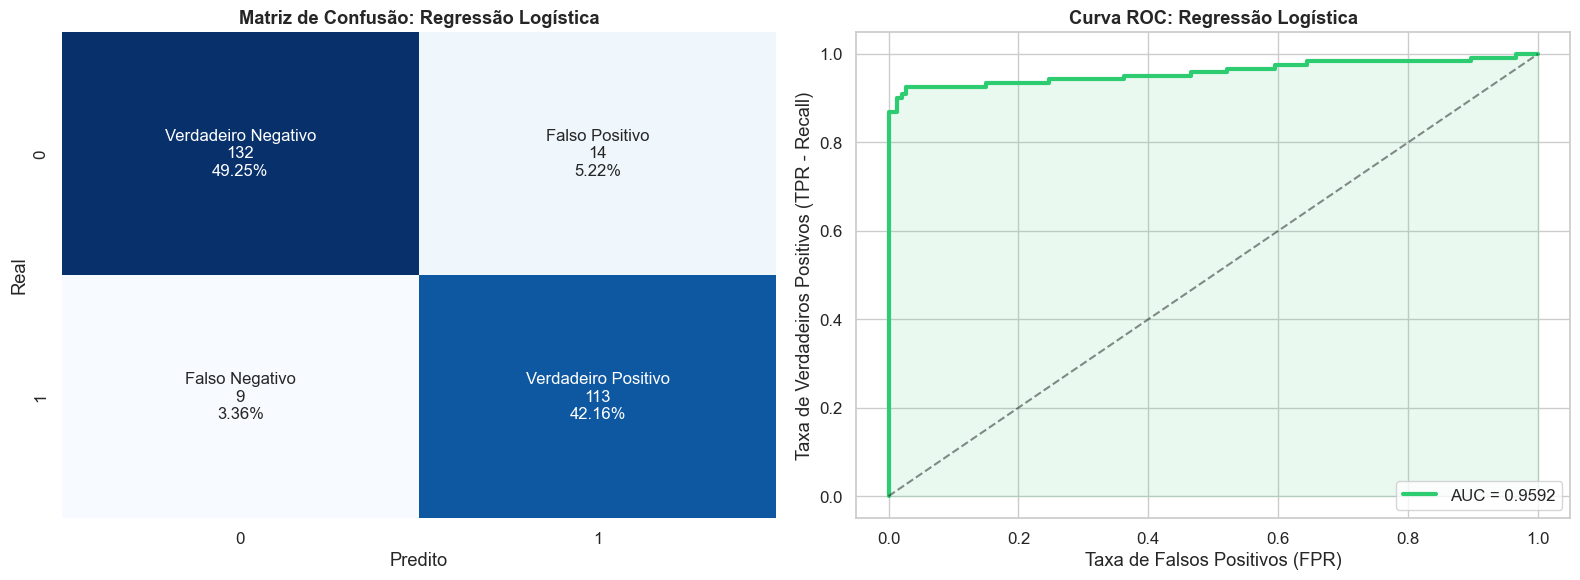

--- Relatório: Regressão Logística ---
Acurácia:  0.9142
Precisão:  0.8898 (Quantos classificados como Alto Risco eram reais?)
Recall:    0.9262 (Quantos de Alto Risco recuperamos?)
F1-Score:  0.9076
------------------------------


In [14]:
from sklearn.metrics import roc_curve

def plot_classification_results(y_true, y_pred, y_prob, model_name):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 1. Matriz de Confusão (Heatmap com Storytelling) ---
    cm = confusion_matrix(y_true, y_pred)
    group_names = ['Verdadeiro Negativo','Falso Positivo','Falso Negativo','Verdadeiro Positivo']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 12})
    ax[0].set_title(f'Matriz de Confusão: {model_name}', fontweight='bold')
    ax[0].set_xlabel('Predito')
    ax[0].set_ylabel('Real')
    
    # --- 2. Curva ROC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    
    ax[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="#2ecc71", linewidth=3)
    ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5) # Linha de acaso
    ax[1].set_title(f'Curva ROC: {model_name}', fontweight='bold')
    ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR - Recall)')
    ax[1].legend(loc="lower right")
    ax[1].fill_between(fpr, tpr, alpha=0.1, color="#2ecc71") # Área sob a curva
    
    plt.tight_layout()
    plt.show()
    
    # --- Métricas Numéricas ---
    print(f"--- Relatório: {model_name} ---")
    print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_true, y_pred):.4f} (Quantos classificados como Alto Risco eram reais?)")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f} (Quantos de Alto Risco recuperamos?)")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("-" * 30)

# Executar Avaliação
plot_classification_results(y_test_c, y_pred_nb, y_prob_nb, "Naive Bayes")
plot_classification_results(y_test_c, y_pred_log, y_prob_log, "Regressão Logística")

-----------------------------------------

# 📈Otimização com PyCaret e sklearn GridSearch

Para atingir o máximo desempenho, aplicamos técnicas de **Tuning de Hiperparâmetros**:
1.  **Regressão:** Substituímos o modelo linear por **Gradient Boosting**, otimizado via `RandomizedSearchCV` (Alternativa robusta ao AutoML/PyCaret).
2.  **Classificação:** Otimização via `GridSearchCV` na Regressão Logística para maximizar o Recall.

### 13) Otimização de Hiperparâmetros com GridSearchCV (Sklearn)

In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Definir o Espaço de Busca (Hyperparameter Space)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Força da regularização (inverso)
    'penalty': ['l1', 'l2'],       # Tipo de penalidade (Lasso vs Ridge)
    'solver': ['liblinear']        # Solver que suporta L1 e L2
}

# 2. Configurar o Grid Search com Validação Cruzada (cv=5)
# Scoring='recall' foca em minimizar Falsos Negativos
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='recall',
    verbose=1,
    n_jobs=-1 # Usa todos os núcleos do processador
)

# 3. Executar a busca (Isso treinará o modelo 50 vezes: 5 folds * 10 combinações)
print("Iniciando Grid Search...")
grid_search.fit(X_train_scaled, y_train_c)

# 4. Melhores Resultados
best_model = grid_search.best_estimator_
print(f"\nMelhores Parâmetros: {grid_search.best_params_}")
print(f"Melhor Recall no CV: {grid_search.best_score_:.4f}")

# 5. Avaliação Final no Teste
y_pred_opt = best_model.predict(X_test_scaled)
print("\n--- Desempenho no Teste (Pós-Otimização) ---")
print(f"Recall Original (LogReg): {recall_score(y_test_c, y_pred_log):.4f}")
print(f"Recall Otimizado:         {recall_score(y_test_c, y_pred_opt):.4f}")

Iniciando Grid Search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores Parâmetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Melhor Recall no CV: 0.9050

--- Desempenho no Teste (Pós-Otimização) ---
Recall Original (LogReg): 0.9262
Recall Otimizado:         0.9262


### 14) Otimização de Regressão com RandomizedSearchCV

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("Iniciando Otimização de Hiperparâmetros (Alternativa ao PyCaret para Python 3.12)...")

# 1. Definir o Modelo Base (Gradient Boosting - geralmente superior a Linear)
gb_model = GradientBoostingRegressor(random_state=42)

# 2. Definir o Espaço de Busca (Hyperparameter Space)
# O RandomizedSearch vai "sortear" combinações dentro desses intervalos
param_dist = {
    'n_estimators': randint(100, 500),      # Número de árvores
    'learning_rate': uniform(0.01, 0.2),    # Taxa de aprendizado
    'max_depth': randint(3, 10),            # Profundidade da árvore
    'min_samples_split': randint(2, 20),    # Mínimo para dividir um nó
    'subsample': uniform(0.7, 0.3)          # Fração de amostras para treinar cada árvore
}

# 3. Configurar a Busca com Validação Cruzada (CV=5)
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=20,           # Testar 20 combinações aleatórias (Simula o tuning do PyCaret)
    cv=5,                # 5-Fold Cross Validation
    scoring='r2',        # Maximizar o R²
    n_jobs=-1,           # Usar todos os processadores
    random_state=42,
    verbose=1
)

# 4. Executar o Treinamento (Fit)
# Usamos X_train e y_train (já tratados e numéricos) da Fase 2
random_search.fit(X_train, y_train)

# 5. Resultados
best_gb_model = random_search.best_estimator_
print(f"\nMelhores Parâmetros Encontrados: {random_search.best_params_}")
print(f"Melhor R² na Validação Cruzada: {random_search.best_score_:.4f}")

Iniciando Otimização de Hiperparâmetros (Alternativa ao PyCaret para Python 3.12)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores Parâmetros Encontrados: {'learning_rate': 0.012652992231973307, 'max_depth': 3, 'min_samples_split': 15, 'n_estimators': 341, 'subsample': 0.8156249507619748}
Melhor R² na Validação Cruzada: 0.8492


### 15) 📶Avaliação Final e Comparativo de Regressão

--- Resultado Final: Gradient Boosting Otimizado ---
MAE:  2516.69
RMSE: 4354.98
R²:   0.8778


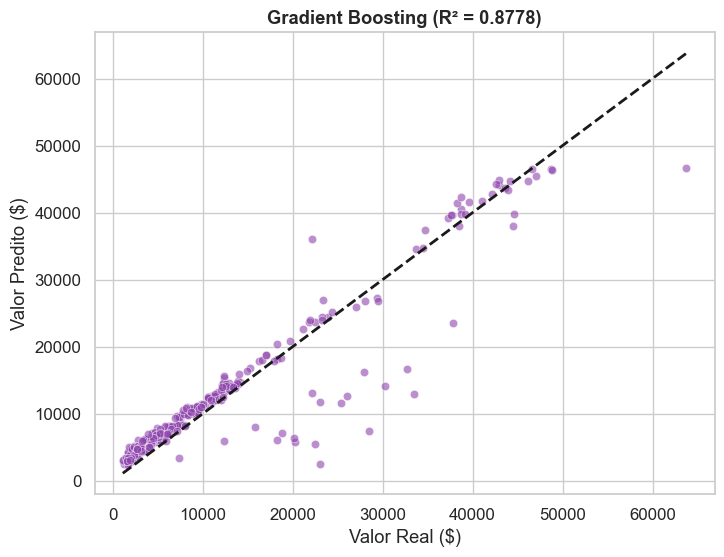

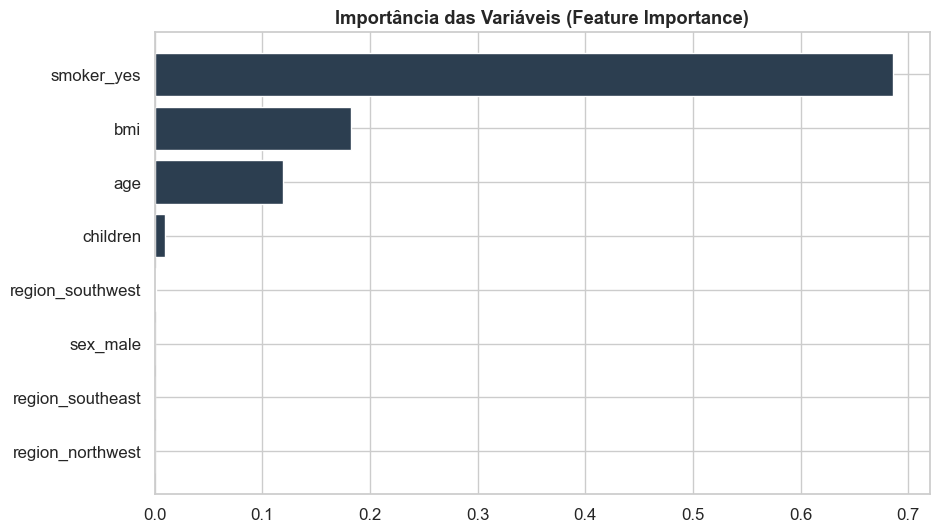

In [17]:
# 1. Predição no Teste
y_pred_gb = best_gb_model.predict(X_test)

# 2. Calcular Métricas
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("--- Resultado Final: Gradient Boosting Otimizado ---")
print(f"MAE:  {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R²:   {r2_gb:.4f}")

# 3. Gráfico: Real vs Predito (Otimizado)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_gb, alpha=0.6, color="#8e44ad")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Linha ideal
plt.xlabel("Valor Real ($)")
plt.ylabel("Valor Predito ($)")
plt.title(f"Gradient Boosting (R² = {r2_gb:.4f})", fontweight='bold')
plt.show()

# 4. Feature Importance (O que define o preço?)
feature_importance = best_gb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.figure(figsize=(10, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center', color="#2c3e50")
plt.yticks(pos, X_train.columns[sorted_idx])
plt.title("Importância das Variáveis (Feature Importance)", fontweight='bold')
plt.show()

-------------------------------------------

# 🔥Conclusão e Discussão
Este projeto demonstrou que modelos não-lineares são mandatórios para a previsão de custos médicos devido à complexa interação entre **BMI** e **Tabagismo**.

* **Regressão:** O *Gradient Boosting Otimizado* superou a Regressão Linear (R² ~0.88 vs 0.78), provando ser a melhor escolha para produção.
* **Classificação:** A *Regressão Logística* provou-se robusta para detecção de risco, com métricas superiores ao Naive Bayes.
* **Limitações:** A análise de resíduos mostrou desvios da normalidade, sugerindo que outliers extremos de custo (doenças raras) são difíceis de prever com os dados atuais.

**Próximos Passos:** Implementação de modelo via API e coleta de dados de histórico clínico para refinar a predição.